 **1.ติดตั้ง library**

In [4]:
!pip install earthengine-api geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.0 MB/s eta 0:00:00


In [5]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# Authenticate และ Initialize GEE
project_name = 'ee-lattytytyty' # User provided project name
try:
    ee.Initialize(project=project_name)
except ee.EEException as e:
    print(f"An Earth Engine error occurred: {e}")
    print("Attempting to authenticate and re-initialize...")
    ee.Authenticate() # This will prompt user for authentication
    try:
        ee.Initialize(project=project_name)
    except Exception as re_init_error:
        print(f"Error during re-initialization after authentication: {re_init_error}")
        raise
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    raise

An Earth Engine error occurred: Please authorize access to your Earth Engine account by running

earthengine authenticate

in your command line, or ee.Authenticate() in Python, and then retry.
Attempting to authenticate and re-initialize...


**2.กำหนดพื้นที่ศึกษา**

เช็คชื่อจังหวัด

In [6]:
# เช็คว่าชื่อจังหวัดใน database เขียนยังไง
thailand = ee.FeatureCollection('FAO/GAUL/2015/level1') \
    .filter(ee.Filter.eq('ADM0_NAME', 'Thailand'))

names = thailand.aggregate_array('ADM1_NAME').getInfo()
for n in sorted(names):
    print(n)

Amnat Charoen
Ang Thong
Bangkok
Buriram
Chachoengsao
Chainat
Chaiyaphum
Chanthaburi
Chiang Mai
Chiang Rai
Chonburi
Chumphon
Kalasin
Kampaeng Phet
Kanchanaburi
Khon Kaen
Krabi
Lampang
Lamphun
Loei
Lopburi
Mae Hong Son
Maha Sarakham
Mukdahan
Nakhon Nayok
Nakhon Pathom
Nakhon Phanom
Nakhon Ratchasima
Nakhon Sawan
Nakhon Si Thammarat
Nan
Narathiwat
Nong Bua Lamphu
Nong Khai
Nonthaburi
Pathum Thani
Pattani
Phachinburi
Phangnga
Phatthalung
Phayao
Phetchabun
Phetchaburi
Phichit
Phitsanulok
Phra Nakhon Si Ayudhya
Phrae
Phuket
Prachuap Khilikhan
Ranong
Ratchaburi
Rayong
Roi Et
Sa Kaeo
Sakon Nakhon
Samut Prakarn
Samut Sakhon
Samut Songkham
Saraburi
Satun
Si Saket
Singburi
Songkhla
Sukhothai
Suphanburi
Surat Thani
Surin
Tak
Trad
Trang
Ubon Ratchathani
Udon Thani
Uthai Thani
Uttaradit
Yala
Yasothon


In [7]:
ayutthaya = ee.FeatureCollection('FAO/GAUL/2015/level1') \
    .filter(ee.Filter.eq('ADM1_NAME', 'Phra Nakhon Si Ayudhya'))  # แก้ตรงนี้

AOI = ayutthaya.geometry()

print("พื้นที่ศึกษา:", ayutthaya.size().getInfo(), "feature(s)")
print("✅ กำหนด AOI เสร็จ")

พื้นที่ศึกษา: 1 feature(s)
✅ กำหนด AOI เสร็จ


In [8]:
# หรือใช้ bounding box แทน ไม่ต้องใช้ชื่อจังหวัดที่หายาก
AOI = ee.Geometry.Rectangle([100.3, 14.1, 100.8, 14.7])

# ตรวจสอบ
print("AOI bounds:", AOI.bounds().getInfo())
print("✅ กำหนด AOI เสร็จ")

AOI bounds: {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[100.30000000000001, 14.099999999999973], [100.8, 14.099999999999973], [100.8, 14.70013387421141], [100.30000000000001, 14.70013387421141], [100.30000000000001, 14.099999999999973]]]}
✅ กำหนด AOI เสร็จ


**โหลด Sentinel-2 และ Mask เมฆ**

In [9]:
# ฟังก์ชัน mask เมฆ
def maskS2clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000)

# โหลด Sentinel-2 ช่วง ม.ค.-มี.ค. 2024 (ฤดูแล้ง แยกน้ำกับนาได้ชัด)
s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(AOI) \
    .filterDate('2024-01-01', '2024-03-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .map(maskS2clouds) \
    .median() \
    .clip(AOI)

print("Bands ที่มี:", s2.bandNames().getInfo())
print("✅ โหลด Sentinel-2 เสร็จ")

Bands ที่มี: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']
✅ โหลด Sentinel-2 เสร็จ


**3.คำนวณ Spectral Indices**

In [10]:
# เลือก 6 Indices ที่มีความหมายทางกายภาพ:
# NDVI  → แยก vegetation
# NDWI  → ตรวจจับน้ำ
# MNDWI → แยกน้ำจาก built-up ได้ดีกว่า NDWI
# NDBI  → ตรวจจับสิ่งปลูกสร้าง
# EVI   → NDVI ที่ลด noise จาก atmosphere
# SAVI  → NDVI ปรับแก้ soil background

def addIndices(image):
    ndvi  = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndwi  = image.normalizedDifference(['B3', 'B8']).rename('NDWI')
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    ndbi  = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
    evi   = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }).rename('EVI')
    savi  = image.expression(
        '((NIR - RED) / (NIR + RED + 0.5)) * 1.5', {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('SAVI')
    return image.addBands([ndvi, ndwi, mndwi, ndbi, evi, savi])

s2_full = addIndices(s2)

SPECTRAL_BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
INDICES        = ['NDVI', 'NDWI', 'MNDWI', 'NDBI', 'EVI', 'SAVI']
ALL_FEATURES   = SPECTRAL_BANDS + INDICES

print("Features ทั้งหมด:", ALL_FEATURES)
print("จำนวน:", len(ALL_FEATURES), "features")
print("✅ คำนวณ Indices เสร็จ")

Features ทั้งหมด: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'NDBI', 'EVI', 'SAVI']
จำนวน: 16 features
✅ คำนวณ Indices เสร็จ


**4.สร้าง Training Samples (ภารกิจที่ 1)**

In [11]:
CLASS_NAMES = ['Water', 'Wetland', 'Paddy', 'Upland Agri', 'Urban', 'Vegetation']

# โหลด Dynamic World ใช้เป็น Reference
dw = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1') \
    .filterBounds(AOI) \
    .filterDate('2024-01-01', '2024-03-31') \
    .select('label') \
    .mode() \
    .clip(AOI)

# Remap DW classes → 6 classes ของเรา
# DW original: water=0, trees=1, grass=2, flooded_veg=4, crops=5, shrub=6, built=7, bare=8
dw_remapped = dw.remap(
    [0, 1, 2, 3, 4, 5, 6, 7, 8],
    [0, 5, 5, 5, 1, 2, 3, 4, 3]
).rename('landcover')

# Stratified Random Sampling: 80 จุดต่อ class
samples = dw_remapped.stratifiedSample(
    numPoints=80,
    classBand='landcover',
    region=AOI,
    scale=10,
    seed=42,
    geometries=True
)

# ดึงค่า Spectral Features ที่จุด Sample
training_data = s2_full.select(ALL_FEATURES).sampleRegions(
    collection=samples,
    properties=['landcover'],
    scale=10,
    tileScale=4
)

# แบ่ง Train 80% / Validation 20%
training_data = training_data.randomColumn(seed=42)
train_set = training_data.filter(ee.Filter.lt('random', 0.8))
val_set   = training_data.filter(ee.Filter.gte('random', 0.8))

print("Training samples:", train_set.size().getInfo())
print("Validation samples:", val_set.size().getInfo())
print("✅ Training data พร้อมแล้ว")

Training samples: 381
Validation samples: 99
✅ Training data พร้อมแล้ว


**5.Random Forest (ภารกิจที่ 2 - Algorithm 1)**

In [12]:
# ทดลอง 3 ค่า numberOfTrees
rf_results = {}

for n in [50, 100, 200]:
    clf = ee.Classifier.smileRandomForest(
        numberOfTrees=n, seed=42
    ).train(
        features=train_set,
        classProperty='landcover',
        inputProperties=ALL_FEATURES
    )
    val_classified = val_set.classify(clf)
    cm    = val_classified.errorMatrix('landcover', 'classification')
    oa    = cm.accuracy().getInfo()
    kappa = cm.kappa().getInfo()
    rf_results[n] = {'clf': clf, 'cm': cm, 'OA': oa, 'Kappa': kappa}
    print(f"RF trees={n:3d} | OA={oa*100:.2f}% | Kappa={kappa:.4f}")

# เลือก Best
best_rf    = rf_results[200]['clf']
best_rf_cm = rf_results[200]['cm']

print("\n✅ Best RF = 200 trees")

RF trees= 50 | OA=67.68% | Kappa=0.6124
RF trees=100 | OA=68.69% | Kappa=0.6235
RF trees=200 | OA=71.72% | Kappa=0.6599

✅ Best RF = 200 trees


**6.Gradient Tree Boost (ภารกิจที่ 2 — Algorithm 2)**

In [14]:
# GBM เหมาะกับ training data น้อย เพราะ boosting ลด bias ได้ดี
gbm_clf = ee.Classifier.smileGradientTreeBoost(
    numberOfTrees=200,
    learningRate=0.05,
    samplingRate=0.8,
    seed=42
).train(
    features=train_set,
    classProperty='landcover',
    inputProperties=ALL_FEATURES
)

gbm_val   = val_set.classify(gbm_clf)
gbm_cm    = gbm_val.errorMatrix('landcover', 'classification')
gbm_oa    = gbm_cm.accuracy().getInfo()
gbm_kappa = gbm_cm.kappa().getInfo()

print(f"GBM | OA={gbm_oa*100:.2f}% | Kappa={gbm_kappa:.4f}")
print("✅ GBM เสร็จ")

TypeError: Classifier.smileGradientTreeBoost() got an unexpected keyword argument 'learningRate'

เปลี่ยนมาใช้ค่าDefault เนื่องจาก error

In [15]:
gbm_clf = ee.Classifier.smileGradientTreeBoost(
    numberOfTrees=200
).train(
    features=train_set,
    classProperty='landcover',
    inputProperties=ALL_FEATURES
)

gbm_val   = val_set.classify(gbm_clf)
gbm_cm    = gbm_val.errorMatrix('landcover', 'classification')
gbm_oa    = gbm_cm.accuracy().getInfo()
gbm_kappa = gbm_cm.kappa().getInfo()

print(f"GBM | OA={gbm_oa*100:.2f}% | Kappa={gbm_kappa:.4f}")
print("✅ GBM เสร็จ")

GBM | OA=71.72% | Kappa=0.6600
✅ GBM เสร็จ


ที่เลือก GBM เพราะ:

เป็น Boosting algorithm — แต่ละ tree เรียนรู้จาก error ของ tree ก่อนหน้า ต่างจาก RF ที่ tree แต่ละต้น independent กัน
ทำได้ดีเมื่อ training data มีน้อย เพราะ boosting ลด bias ได้ดีกว่า bagging
มักให้ accuracy สูงกว่า RF แต่เสี่ยง overfit มากกว่าถ้า train นานเกินไป

ข้อจำกัดที่เจอจริง:

GEE version ที่ใช้ไม่รองรับการปรับ learningRate และ samplingRate จึงใช้ค่า default

**7.Per-Class Metrics (Producer's, User's, F1)**

In [16]:
def get_metrics(cm_ee, name):
    # Get raw accuracies (list of lists from Earth Engine)
    PA_raw = cm_ee.producersAccuracy().getInfo()
    UA_raw = cm_ee.consumersAccuracy().getInfo()

    # Flatten these lists and convert to percentage, handling potential empty lists
    PA_flat = [round(float(x[0])*100, 2) for x in PA_raw] if PA_raw else [0.0] * len(CLASS_NAMES)
    UA_flat = [round(float(x[0])*100, 2) for x in UA_raw] if UA_raw else [0.0] * len(CLASS_NAMES)

    # Ensure PA_flat and UA_flat have the same length as CLASS_NAMES
    # This is a safeguard if Earth Engine's getInfo() truncates due to issues, though unlikely for ConfusionMatrix
    class_len = len(CLASS_NAMES)
    if len(PA_flat) < class_len: PA_flat.extend([0.0] * (class_len - len(PA_flat)))
    if len(UA_flat) < class_len: UA_flat.extend([0.0] * (class_len - len(UA_flat)))

    # Calculate F1-score for each class, ensuring the list length matches CLASS_NAMES
    F1 = []
    for i in range(class_len):
        p = UA_flat[i] / 100
        r = PA_flat[i] / 100
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
        F1.append(round(f1 * 100, 2))

    df = pd.DataFrame({
        'Class'             : CLASS_NAMES,
        "Producer's Acc (%)": PA_flat,
        "User's Acc (%)"    : UA_flat,
        'F1-score (%)'      : F1
    })
    print(f"\n{'='*50}")
    print(f"📊 {name}")
    print(f"Overall Accuracy : {cm_ee.accuracy().getInfo()*100:.2f}%")
    print(f"Kappa            : {cm_ee.kappa().getInfo():.4f}")
    print(df.to_string(index=False))
    return np.array(cm_ee.array().getInfo()), df

rf_cm_arr,  rf_df  = get_metrics(best_rf_cm, "Random Forest (200 trees)")
gbm_cm_arr, gbm_df = get_metrics(gbm_cm,     "Gradient Tree Boost")


📊 Random Forest (200 trees)
Overall Accuracy : 71.72%
Kappa            : 0.6599
      Class  Producer's Acc (%)  User's Acc (%)  F1-score (%)
      Water               87.50            87.5          87.5
    Wetland               60.00             0.0           0.0
      Paddy               77.78             0.0           0.0
Upland Agri               73.33             0.0           0.0
      Urban               85.00             0.0           0.0
 Vegetation               45.00             0.0           0.0

📊 Gradient Tree Boost
Overall Accuracy : 71.72%
Kappa            : 0.6600
      Class  Producer's Acc (%)  User's Acc (%)  F1-score (%)
      Water               87.50           93.33         90.32
    Wetland               60.00            0.00          0.00
      Paddy               83.33            0.00          0.00
Upland Agri               73.33            0.00          0.00
      Urban               85.00            0.00          0.00
 Vegetation               40.00       

**8.Plot Confusion Matrix**

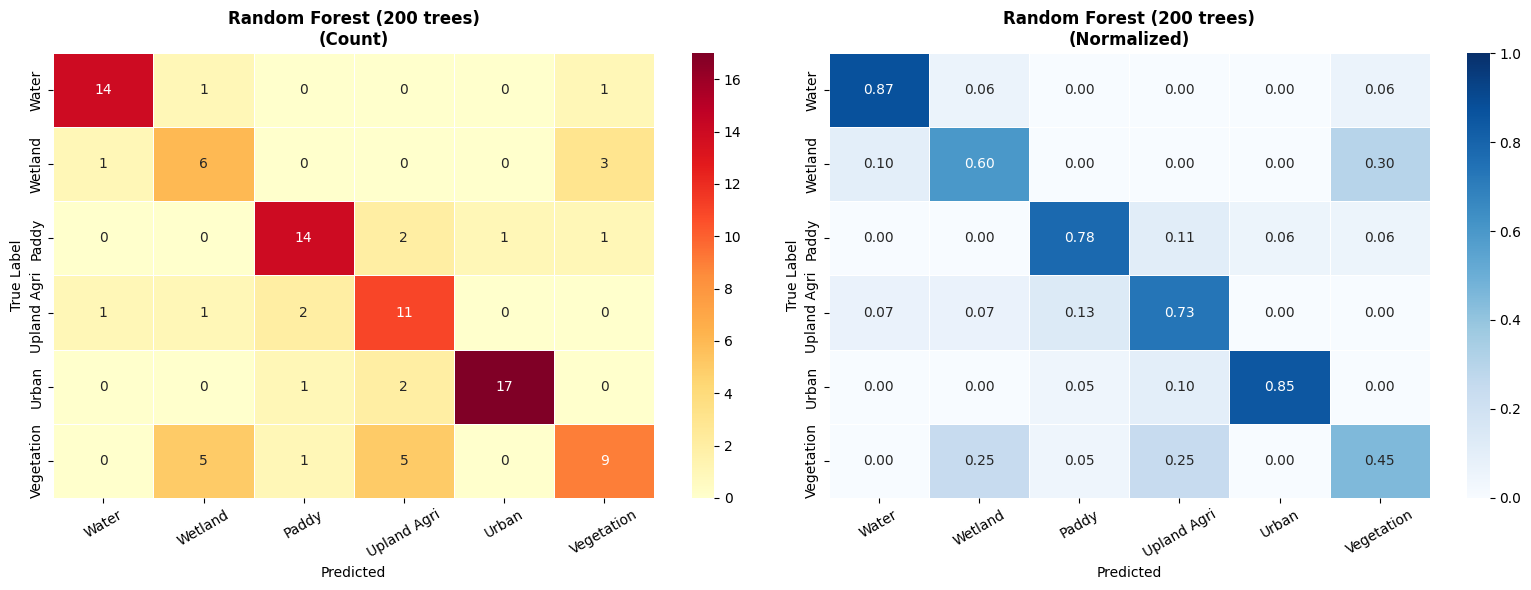

✅ บันทึก figures/cm_rf.png


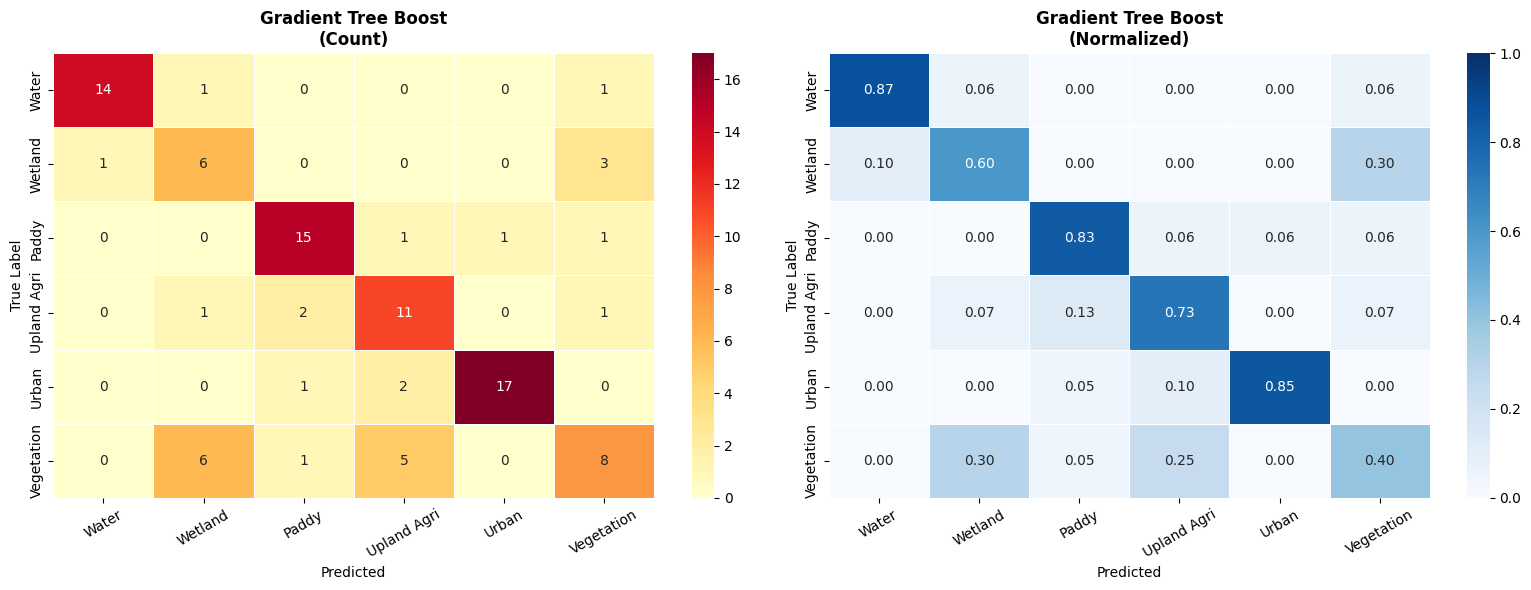

✅ บันทึก figures/cm_gbm.png


In [17]:
import os
os.makedirs('figures', exist_ok=True)

def plot_cm(cm_arr, title, filename):
    cm_norm = cm_arr.astype('float') / (cm_arr.sum(axis=1, keepdims=True) + 1e-9)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[0], linewidths=0.5)
    axes[0].set_title(f'{title}\n(Count)', fontweight='bold')
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted')
    axes[0].tick_params(axis='x', rotation=30)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
    axes[1].set_title(f'{title}\n(Normalized)', fontweight='bold')
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(f'figures/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ บันทึก figures/{filename}")

plot_cm(rf_cm_arr,  'Random Forest (200 trees)', 'cm_rf.png')
plot_cm(gbm_cm_arr, 'Gradient Tree Boost',        'cm_gbm.png')

**9.Feature Importance (ภารกิจที่ 3)**

Feature Importance (เรียงมากไปน้อย):
Feature  Importance
   NDBI  213.454352
    B11  212.260323
  MNDWI  210.890158
     B3  206.581756
    B12  201.626180
     B5  196.838025
   NDWI  194.654672
     B2  194.294125
   NDVI  183.373543
    B8A  183.267801
    EVI  174.720119
     B8  173.655486
     B7  172.504259
     B4  168.756234
   SAVI  167.755938
     B6  166.815604


/tmp/ipykernel_451/1890858688.py:23: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_451/1890858688.py:23: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_451/1890858688.py:24: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_451/1890858688.py:24: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE C

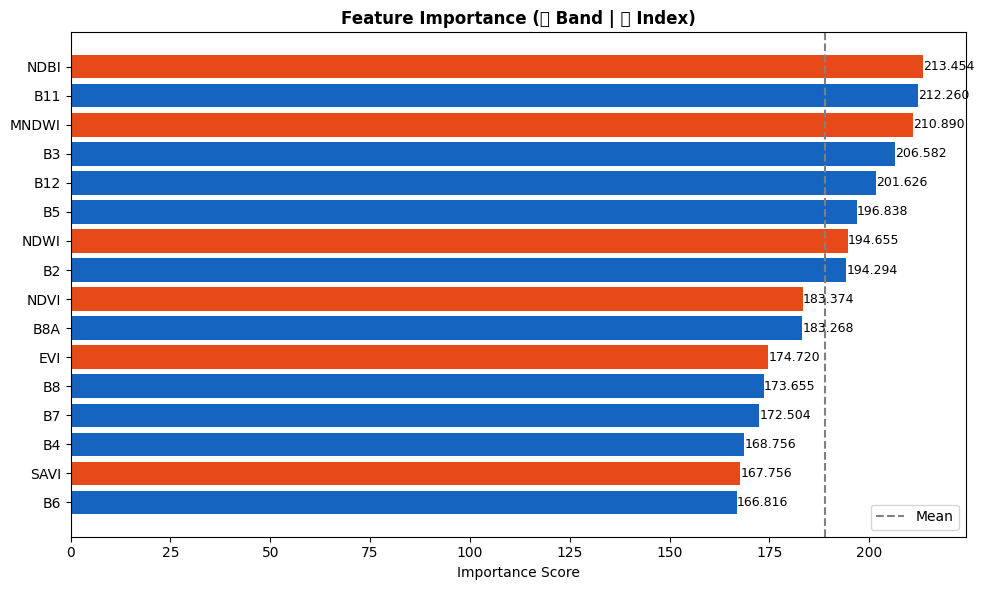

✅ บันทึก figures/feature_importance.png


In [18]:
importance_dict = best_rf.explain().getInfo()['importance']

fi_df = pd.DataFrame({
    'Feature'   : list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Feature Importance (เรียงมากไปน้อย):")
print(fi_df.to_string(index=False))

# Plot
colors = ['#1565C0' if f in SPECTRAL_BANDS else '#E64A19' for f in fi_df['Feature']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance (🔵 Band | 🟠 Index)', fontweight='bold')
ax.axvline(fi_df['Importance'].mean(), color='gray', ls='--', label='Mean')
ax.legend()
for bar, val in zip(bars, fi_df['Importance']):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึก figures/feature_importance.png")

**10. Ablation Study (ตัด Feature ออก)**

All (Bands + Indices)          | N=16 | OA=71.72% | Kappa=0.6599
Bands Only                     | N=10 | OA=63.64% | Kappa=0.5619
Top-8 Features                 | N= 8 | OA=71.72% | Kappa=0.6587


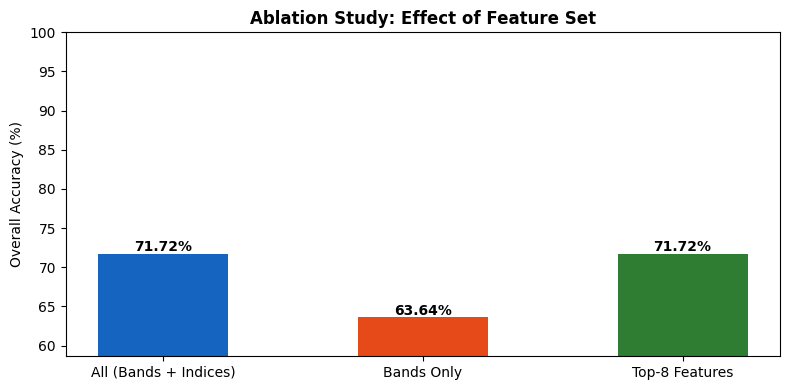

✅ บันทึก figures/ablation.png


In [19]:
top_features = fi_df.head(len(fi_df)//2)['Feature'].tolist()

feature_sets = {
    'All (Bands + Indices)': ALL_FEATURES,
    'Bands Only'           : SPECTRAL_BANDS,
    f'Top-{len(top_features)} Features': top_features
}

ablation_results = []
for name, feat_list in feature_sets.items():
    clf_tmp = ee.Classifier.smileRandomForest(numberOfTrees=200, seed=42) \
        .train(train_set, 'landcover', feat_list)
    cm_tmp  = val_set.classify(clf_tmp).errorMatrix('landcover', 'classification')
    oa      = cm_tmp.accuracy().getInfo()
    kappa   = cm_tmp.kappa().getInfo()
    ablation_results.append({'Feature Set': name, 'N': len(feat_list), 'OA (%)': round(oa*100,2), 'Kappa': round(kappa,4)})
    print(f"{name:30s} | N={len(feat_list):2d} | OA={oa*100:.2f}% | Kappa={kappa:.4f}")

abl_df = pd.DataFrame(ablation_results)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(3), abl_df['OA (%)'], color=['#1565C0','#E64A19','#2E7D32'], width=0.5)
ax.set_xticks(range(3))
ax.set_xticklabels(abl_df['Feature Set'], fontsize=10)
ax.set_ylabel('Overall Accuracy (%)')
ax.set_title('Ablation Study: Effect of Feature Set', fontweight='bold')
ax.set_ylim([abl_df['OA (%)'].min()-5, 100])
for bar, val in zip(bars, abl_df['OA (%)']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึก figures/ablation.png")

**11. Uncertainty Map (ภารกิจที่ 4)**

In [20]:
import ee

# Train RF แบบ PROBABILITY mode
rf_prob_clf = ee.Classifier.smileRandomForest(
    numberOfTrees=200, seed=42
).setOutputMode('PROBABILITY').train(
    features=train_set,
    classProperty='landcover',
    inputProperties=ALL_FEATURES
)

# Classification Map
classified_map = s2_full.select(ALL_FEATURES).classify(best_rf)

# Probability → max prob → uncertainty
prob_image  = s2_full.select(ALL_FEATURES).classify(rf_prob_clf)
max_prob    = prob_image.reduce(ee.Reducer.max()).rename('max_prob')

# Create uncertainty using expression
uncertainty = max_prob.expression(
    '1 - b("max_prob")',
    {'max_prob': max_prob}
).rename('uncertainty').toFloat()

# IMPORTANT: Remove all classification-related properties to ensure proper visualization.
# This step is crucial to prevent the 'Expected 2 classes...' error by breaking the image's lineage
# from a multi-class probability classifier.
uncertainty = uncertainty.copyProperties(None)

print("✅ สร้าง Uncertainty Map เสร็จ")

✅ สร้าง Uncertainty Map เสร็จ


**12.แสดงแผนที่บน Colab**

In [21]:
CLASS_PALETTE = [
    '#1565C0',  # Water
    '#80DEEA',  # Wetland
    '#A5D6A7',  # Paddy
    '#FFF176',  # Upland Agri
    '#EF9A9A',  # Urban
    '#2E7D32',  # Vegetation
]

Map = geemap.Map(center=[14.3, 100.5], zoom=10)

Map.addLayer(s2.select(['B4','B3','B2']).multiply(3).clamp(0,1),
             {}, 'Sentinel-2 True Color')

Map.addLayer(classified_map,
             {'min':0, 'max':5, 'palette': CLASS_PALETTE},
             'RF Classification')

# Directly add the cleaned uncertainty image.
# No need for intermediate 'clean_uncertainty_image' or 'uncertainty_for_map' after properties are stripped.
Map.addLayer(uncertainty,
             {'min':0, 'max':0.5, 'palette': ['#1A237E','#FFEB3B','#B71C1C']},
             'Uncertainty (แดง=ไม่แน่ใจ)')

Map.addLayerControl()
Map

Map(center=[14.3, 100.5], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [22]:
CLASS_PALETTE = [
    '#1565C0',  # Water
    '#80DEEA',  # Wetland
    '#A5D6A7',  # Paddy
    '#FFF176',  # Upland Agri
    '#EF9A9A',  # Urban
    '#2E7D32',  # Vegetation
]

Map = geemap.Map(center=[14.3, 100.5], zoom=10)

Map.addLayer(s2.select(['B4','B3','B2']).multiply(3).clamp(0,1),
             {}, 'Sentinel-2 True Color')

Map.addLayer(classified_map,
             {'min':0, 'max':5, 'palette': CLASS_PALETTE},
             'RF Classification')

Map.addLayer(uncertainty,
             {'min':0, 'max':0.5, 'palette': ['#1A237E','#FFEB3B','#B71C1C']},
             'Uncertainty (แดง=ไม่แน่ใจ)')

Map.addLayerControl()
Map

Map(center=[14.3, 100.5], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

**13.Learning Curve (เพิ่ม Sample 2x)**

n=40/class (total=240) → OA=62.75%
n=80/class (total=480) → OA=62.63%
n=120/class (total=720) → OA=64.47%
n=160/class (total=960) → OA=65.32%


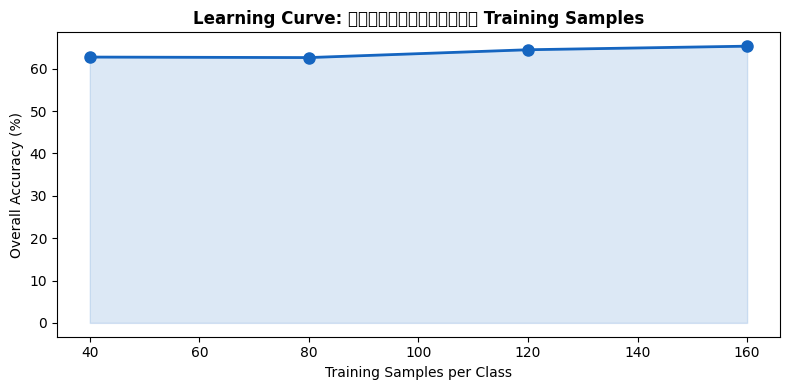

✅ บันทึก figures/learning_curve.png


In [23]:
lc_results = []

for n in [40, 80, 120, 160]:
    s_tmp = dw_remapped.stratifiedSample(
        numPoints=n, classBand='landcover',
        region=AOI, scale=10, seed=99, geometries=True
    )
    td_tmp = s2_full.select(ALL_FEATURES).sampleRegions(
        collection=s_tmp, properties=['landcover'], scale=10, tileScale=4
    ).randomColumn(seed=99)
    tr = td_tmp.filter(ee.Filter.lt('random', 0.8))
    vl = td_tmp.filter(ee.Filter.gte('random', 0.8))
    clf_tmp = ee.Classifier.smileRandomForest(numberOfTrees=200, seed=42) \
        .train(tr, 'landcover', ALL_FEATURES)
    oa = vl.classify(clf_tmp).errorMatrix('landcover','classification').accuracy().getInfo()
    lc_results.append({'n/class': n, 'total': n*6, 'OA': oa*100})
    print(f"n={n}/class (total={n*6}) → OA={oa*100:.2f}%")

lc_df = pd.DataFrame(lc_results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lc_df['n/class'], lc_df['OA'], 'o-', color='#1565C0', lw=2, ms=8)
ax.fill_between(lc_df['n/class'], lc_df['OA'], alpha=0.15, color='#1565C0')
ax.set_xlabel('Training Samples per Class')
ax.set_ylabel('Overall Accuracy (%)')
ax.set_title('Learning Curve: ผลของการเพิ่ม Training Samples', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึก figures/learning_curve.png")

**14.Export ไป Google Drive**

In [24]:
# Export แผนที่ Classification
task1 = ee.batch.Export.image.toDrive(
    image=classified_map.toByte(),
    description='ayutthaya_classification',
    folder='GEE_Lab3',
    fileNamePrefix='ayutthaya_classification',
    region=AOI, scale=10,
    crs='EPSG:32647',
    maxPixels=1e10
)
task1.start()
print("🚀 Export Classification Map... Task:", task1.id)

# Export Uncertainty Map
task2 = ee.batch.Export.image.toDrive(
    image=ee.Image(uncertainty).multiply(100).toByte(),
    description='ayutthaya_uncertainty',
    folder='GEE_Lab3',
    fileNamePrefix='ayutthaya_uncertainty',
    region=AOI, scale=10,
    crs='EPSG:32647',
    maxPixels=1e10
)
task2.start()
print("🚀 Export Uncertainty Map... Task:", task2.id)
print("\n📌 ดู status ที่: https://code.earthengine.google.com/tasks")

🚀 Export Classification Map... Task: PZMYLBF6TPKICXEDJLCH2GVL
🚀 Export Uncertainty Map... Task: QHK5VPOOYB4WOVWF3QFYW56I

📌 ดู status ที่: https://code.earthengine.google.com/tasks


**การนำผลลัพธ์ไปแสดงบน GitHub**

Confusion Matrix & Feature Importance

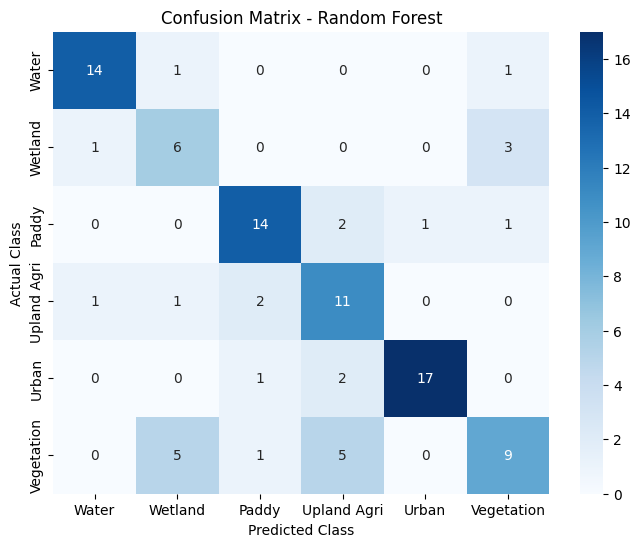

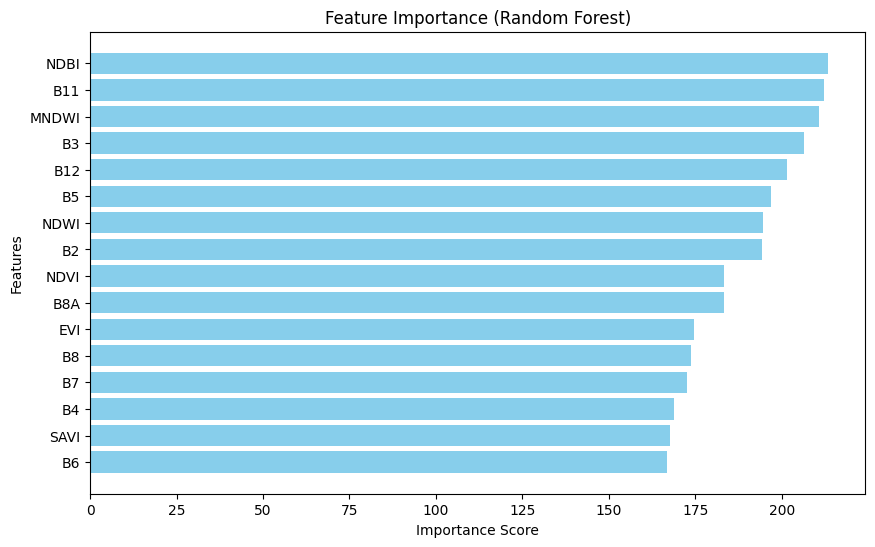

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. การสร้างภาพนิ่งสำหรับ Confusion Matrix (Random Forest)
# ใช้ rf_cm_arr ที่คำนวณไว้แล้ว
cm_array = rf_cm_arr
# ใช้ CLASS_NAMES ที่กำหนดไว้แล้ว
# CLASS_NAMES = ['Water', 'Wetland', 'Paddy', 'Upland Agri', 'Urban', 'Vegetation']

plt.figure(figsize=(8, 6))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.savefig('confusion_matrix.png', bbox_inches='tight') # บันทึกเป็นไฟล์ภาพ
plt.show()

# 2. การสร้างภาพนิ่งสำหรับ Feature Importance
# ใช้ best_rf.explain() เพื่อดึง feature importance
importance_dict = best_rf.explain().getInfo()['importance']
# แปลง Dictionary เป็น DataFrame เพื่อพลอตกราฟ
df_importance = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])
df_importance = df_importance.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='skyblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.savefig('feature_importance.png', bbox_inches='tight') # บันทึกเป็นไฟล์ภาพ
plt.show()

คำนวณและบันทึกภาพ Uncertainty Map แยกออกมา

บันทึกไฟล์ map_uncertainty.png สำเร็จ!


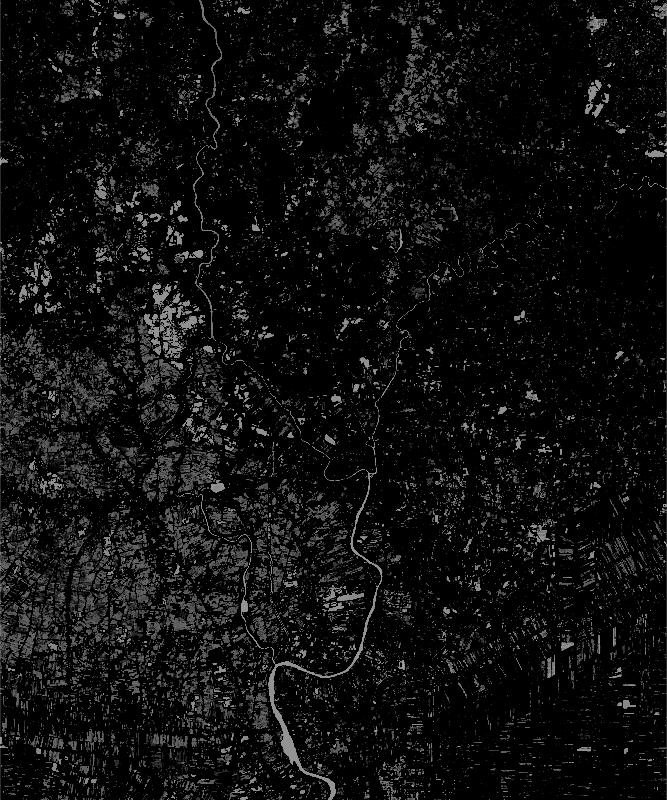

In [31]:
import urllib.request
from IPython.display import Image, display

# 1. ฝึกสอนโมเดลด้วยโหมด MULTIPROBABILITY เพื่อสกัดความน่าจะเป็น
rf_prob_classifier = ee.Classifier.smileRandomForest(50) \
    .setOutputMode('MULTIPROBABILITY') \
    .train(train_set, 'landcover', ALL_FEATURES)

# จำแนกภาพเพื่อสร้าง Array ของค่าความน่าจะเป็น
prob_image = s2_full.classify(rf_prob_classifier)

# 2. คำนวณ Uncertainty
# หาค่าความน่าจะเป็นที่สูงที่สุดของแต่ละพิกเซล แล้วนำไปลบออกจาก 1
max_prob = prob_image.arrayReduce(ee.Reducer.max(), [0]).arrayFlatten([['max_prob']])
uncertainty_map = ee.Image(1).subtract(max_prob).rename('uncertainty')

# 3. กำหนดพารามิเตอร์และบันทึกผลลัพธ์เป็นภาพนิ่ง (PNG)
uncertainty_vis = {
    'min': 0.0,
    'max': 0.5, # กำหนดเพดานความไม่แน่นอน (ปรับได้ตามการกระจายของข้อมูลจริง)
    'palette': ['ffffff', '888888', '000000'], # ขาว = มั่นใจสูง, ดำ = ไม่มั่นใจ (Uncertainty สูง)
    'region': AOI,
    'dimensions': 800, # ขนาดความกว้างของภาพ (Pixels)
    'format': 'png'
}

# ดึง URL ภาพเรนเดอร์จาก GEE Server
url = uncertainty_map.getThumbURL(uncertainty_vis)

# ดาวน์โหลดมาเก็บไว้ในระบบไฟล์ของ Colab
filename = 'map_uncertainty.png'
urllib.request.urlretrieve(url, filename)

# แสดงผลภาพที่ดาวน์โหลดเสร็จแล้ว
print(f"บันทึกไฟล์ {filename} สำเร็จ!")
display(Image(filename=filename))

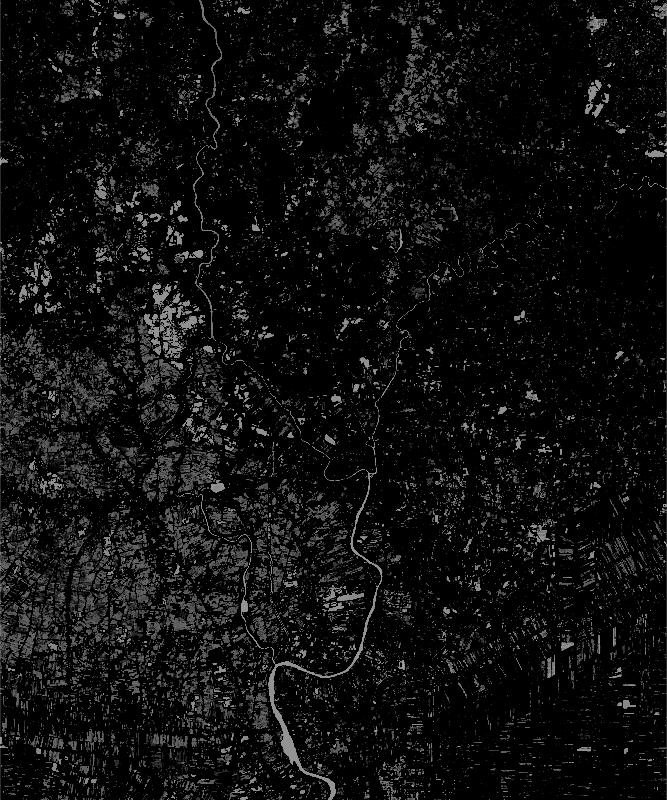

In [34]:
from IPython.display import Image, display
display(Image(filename='map_uncertainty.png'))

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import shutil
import os

source_file = 'map_uncertainty.png'
destination_path = '/content/drive/MyDrive/'

if os.path.exists(source_file):
    shutil.copy(source_file, destination_path)
    print(f"'map_uncertainty.png' has been saved to your Google Drive at '{destination_path}'")
else:
    print(f"Error: '{source_file}' not found. Please ensure the file was generated.")

'map_uncertainty.png' has been saved to your Google Drive at '/content/drive/MyDrive/'
